# **TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo.**

En este trabajo se analizará el fenómeno de desparramo espectral que aparece al calcular la Transformada Discreta de Fourier (DFT) de una señal de duración finita.

Se trabajará con señales senoidales de frecuencia:

$$
f_0=k_0\frac{f_s}{N}=k_0\Delta f
$$

donde:

$$
\Delta f=\frac{f_s}{N}
$$

es la resolución frecuencial asociada a una DFT de N muestras.

Se utilizarán tres valores de k_0:

$$
k_0=\frac{N}{4}
$$

$$
k_0=\frac{N}{4}+0.25
$$

$$
k_0=\frac{N}{4}+0.5
$$

De esta manera se estudiará el efecto de introducir pequeñas desintonías respecto de los bins de frecuencia de la DFT.

Todas las señales serán generadas con potencia unitaria.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros generales
fs = 1000       # Frecuencia de muestreo [Hz]
N = 1000        # Cantidad de muestras

# Vector temporal
tt = np.arange(N) / fs

# Resolución frecuencial
df = fs / N

print("fs =", fs, "Hz")
print("N =", N)
print("Δf =", df, "Hz")
print("Duración del registro =", N/fs, "s")

fs = 1000 Hz
N = 1000
Δf = 1.0 Hz
Duración del registro = 1.0 s


## 1. Generación de las señales senoidales

La señal utilizada será:

$$
s[n]=A\sin\left(2\pi f_0\frac{n}{f_s}\right)
$$

La potencia media de una señal senoidal de amplitud A es:

$$
P_s=\frac{A^2}{2}
$$

Para obtener potencia unitaria:

$$
P_s=1
$$

se selecciona:

$$
A=\sqrt{2}
$$

Con N=1000 y f_s=1000 Hz:

$$
\Delta f=\frac{1000}{1000}=1\text{ Hz}
$$

Los tres valores de frecuencia estudiados serán entonces:

$$
f_{01}=250\text{ Hz}
$$

$$
f_{02}=250.25\text{ Hz}
$$

$$
f_{03}=250.5\text{ Hz}
$$

La primera señal coincide exactamente con un bin de la DFT, mientras que las otras dos presentan una pequeña desintonía respecto de la grilla frecuencial.

In [4]:
# Amplitud necesaria para potencia unitaria
A = np.sqrt(2)

# Valores de k0
k01 = N/4
k02 = N/4 + 0.25
k03 = N/4 + 0.5

# Frecuencias correspondientes
f01 = k01 * fs / N
f02 = k02 * fs / N
f03 = k03 * fs / N

print("f01 =", f01, "Hz")
print("f02 =", f02, "Hz")
print("f03 =", f03, "Hz")

# Generación de las tres señales
s1 = A * np.sin(2*np.pi*f01*tt)
s2 = A * np.sin(2*np.pi*f02*tt)
s3 = A * np.sin(2*np.pi*f03*tt)

print("\nPotencia s1 =", np.mean(s1**2))
print("Potencia s2 =", np.mean(s2**2))
print("Potencia s3 =", np.mean(s3**2))

f01 = 250.0 Hz
f02 = 250.25 Hz
f03 = 250.5 Hz

Potencia s1 = 1.0000000000000002
Potencia s2 = 0.9989999999999998
Potencia s3 = 1.0000000000000004


Las tres señales poseen aproximadamente potencia unitaria.

Aunque las frecuencias difieren solamente en fracciones de Hertz, las tres señales no poseen exactamente la misma relación con la grilla frecuencial de la DFT.

La primera frecuencia es un múltiplo entero de la resolución:

$$
f_{01}=250\Delta f
$$

mientras que las otras se encuentran desplazadas:

$$
f_{02}=250.25\Delta f
$$

$$
f_{03}=250.5\Delta f
$$

En el dominio temporal las tres señales presentan un aspecto prácticamente idéntico debido a que la diferencia entre sus frecuencias es muy pequeña.

Sin embargo, su representación mediante la DFT resultará considerablemente diferente.

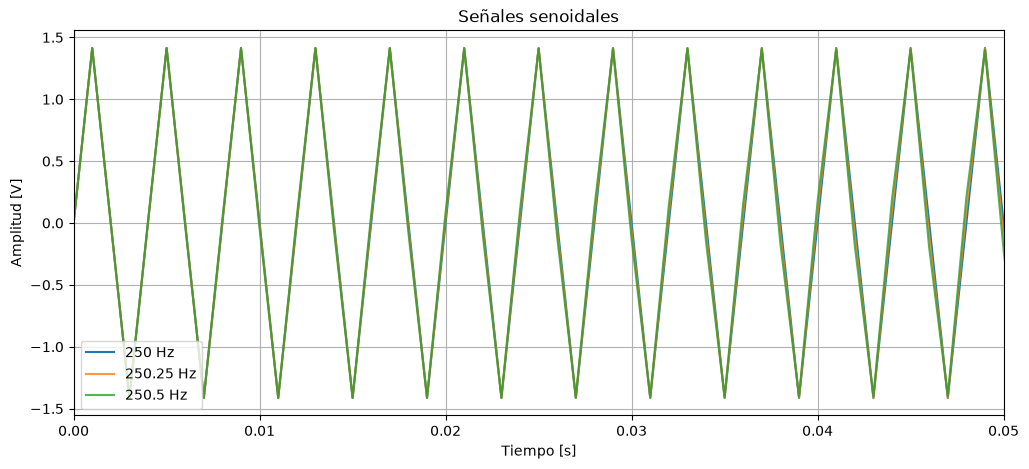

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(tt, s1, label="250 Hz")
plt.plot(tt, s2, label="250.25 Hz", alpha=0.8)
plt.plot(tt, s3, label="250.5 Hz", alpha=0.8)

plt.title("Señales senoidales")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")

plt.xlim(0, 0.05)

plt.grid()
plt.legend()

plt.show()

# Parte a: análisis del desparramo espectral

Para analizar las señales se calculará una estimación de su densidad espectral de potencia (PSD).

A partir de la DFT:

$$
X[k]=\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}
$$

se obtiene una PSD unilateral.

El espectro unilateral contiene solamente las frecuencias comprendidas entre:

$$
0\le f\le\frac{f_s}{2}
$$

Por tratarse de señales reales, la potencia correspondiente a las frecuencias negativas puede incorporarse duplicando las componentes positivas, excepto las componentes de continua y Nyquist.

In [6]:
def calcular_psd(x, fs, nfft=None):
    
    N_original = len(x)
    
    # Si no se especifica nfft, se utiliza la longitud original
    if nfft is None:
        nfft = N_original
    
    # FFT unilateral
    X = np.fft.rfft(x, n=nfft)
    
    # PSD
    PSD = np.abs(X)**2 / (fs * N_original)
    
    # Corrección para espectro unilateral
    if nfft % 2 == 0:
        PSD[1:-1] *= 2
    else:
        PSD[1:] *= 2
    
    # Vector de frecuencias
    f = np.fft.rfftfreq(nfft, d=1/fs)
    
    return f, PSD

f, PSD1 = calcular_psd(s1, fs)
_, PSD2 = calcular_psd(s2, fs)
_, PSD3 = calcular_psd(s3, fs)

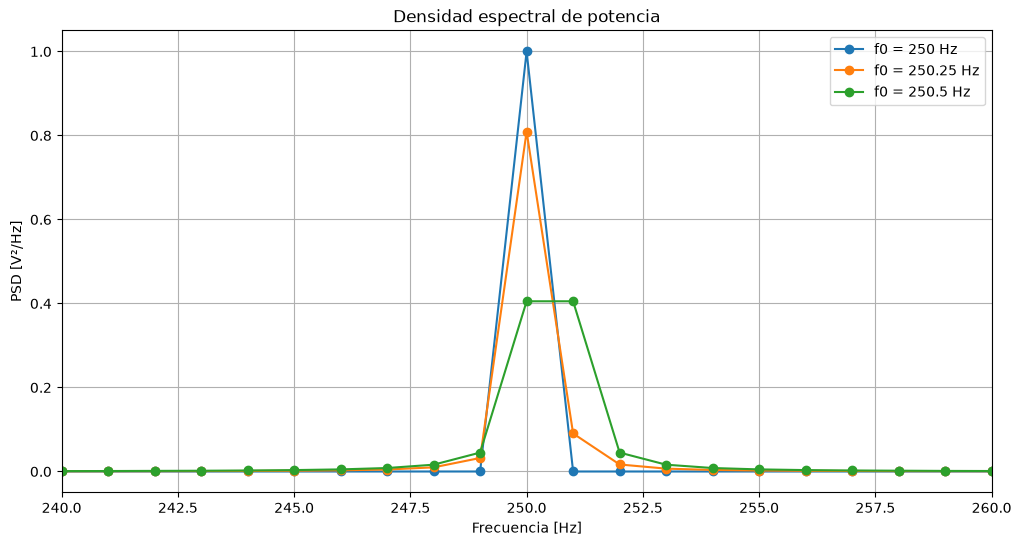

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(f, PSD1, marker="o", label="f0 = 250 Hz")
plt.plot(f, PSD2, marker="o", label="f0 = 250.25 Hz")
plt.plot(f, PSD3, marker="o", label="f0 = 250.5 Hz")

plt.title("Densidad espectral de potencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")

plt.xlim(240, 260)

plt.grid()
plt.legend()

plt.show()

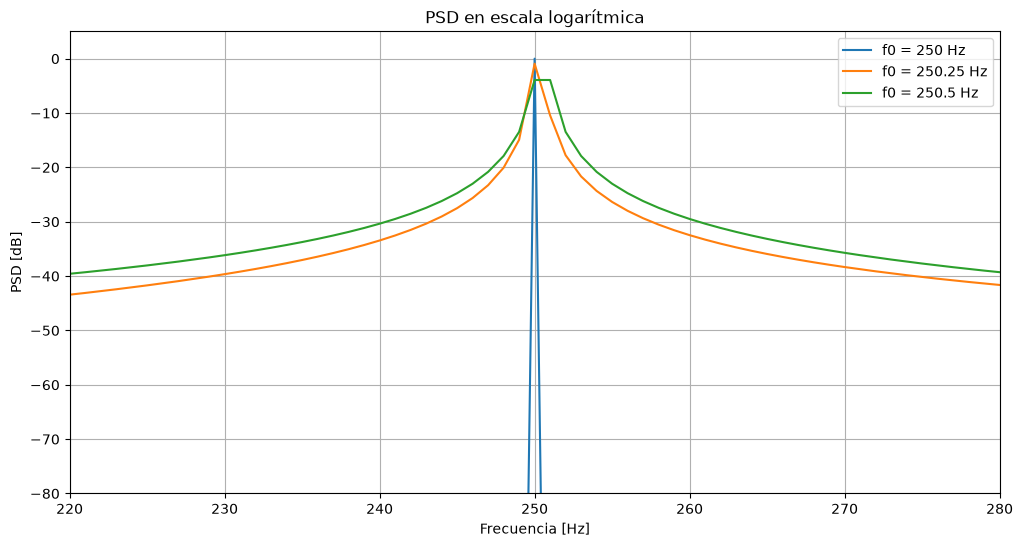

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    f,
    10*np.log10(PSD1 + 1e-20),
    label="f0 = 250 Hz"
)

plt.plot(
    f,
    10*np.log10(PSD2 + 1e-20),
    label="f0 = 250.25 Hz"
)

plt.plot(
    f,
    10*np.log10(PSD3 + 1e-20),
    label="f0 = 250.5 Hz"
)

plt.title("PSD en escala logarítmica")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")

plt.xlim(220, 280)
plt.ylim(-80, 5)

plt.grid()
plt.legend()

plt.show()

## Discusión de los resultados

Para la señal de 250 Hz ocurre que:

$$
f_0=250\Delta f
$$

por lo que su frecuencia coincide exactamente con uno de los bins de la DFT.

El registro contiene un número entero de ciclos y, por lo tanto, prácticamente toda la potencia de la señal queda concentrada en un único bin espectral.

En cambio, para:

$$
f_0=250.25\text{ Hz}
$$

y:

$$
f_0=250.5\text{ Hz}
$$

la frecuencia de la señal no coincide con los bins disponibles en la DFT.

Como consecuencia, su potencia no puede ser representada mediante una única componente y aparece distribuida entre múltiples bins vecinos. Este fenómeno recibe el nombre de desparramo espectral.

La desintonía de 0.5 Hz corresponde además a una situación especialmente desfavorable, debido a que la frecuencia se encuentra exactamente a mitad de camino entre dos bins consecutivos. En esta condición la energía de la componente principal se reparte entre ambos bins y el máximo observado en cada uno de ellos disminuye.

## Interpretación del desparramo espectral

La DFT no analiza una señal senoidal de duración infinita, sino un fragmento de solamente \(N\) muestras.

Seleccionar un intervalo finito de una señal equivale a multiplicarla por una ventana rectangular.

Si dentro de dicho intervalo existe un número entero de ciclos de la senoidal, los extremos del registro son compatibles con la periodicidad implícita de la DFT.

En cambio, si la frecuencia se encuentra desintonizada respecto de los bins, al repetir periódicamente el registro aparecen discontinuidades entre el final de un bloque y el comienzo del siguiente.

Estas discontinuidades requieren múltiples componentes frecuenciales para ser representadas, produciendo el desparramo espectral.

Por lo tanto, el fenómeno no implica que hayan aparecido nuevas frecuencias físicas en la señal original. Es una consecuencia de observar una señal durante un intervalo temporal finito y representarla mediante una cantidad discreta de frecuencias.

## Parte b: verificación de potencia mediante Parseval

La identidad de Parseval establece una equivalencia entre la energía o potencia calculada en el dominio temporal y la calculada en el dominio frecuencial.

Por lo tanto, la integral de la densidad espectral de potencia debe coincidir con la potencia media de la señal:

$$
P_x=\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2
$$

y, en el dominio frecuencial:

$$
P_x \approx \sum_k PSD[k]\Delta f
$$

Dado que las señales fueron generadas con potencia normalizada, ambos métodos deberían producir aproximadamente:

$$
P_x=1
$$

In [12]:
# Potencia calculada en el dominio temporal
P1_t = np.mean(s1**2)
P2_t = np.mean(s2**2)
P3_t = np.mean(s3**2)

# Potencia obtenida integrando las PSD
P1_f = np.sum(PSD1) * df
P2_f = np.sum(PSD2) * df
P3_f = np.sum(PSD3) * df

print("Señal 1")
print("Potencia temporal   =", P1_t)
print("Potencia frecuencial =", P1_f)

print("\nSeñal 2")
print("Potencia temporal   =", P2_t)
print("Potencia frecuencial =", P2_f)

print("\nSeñal 3")
print("Potencia temporal   =", P3_t)
print("Potencia frecuencial =", P3_f)

Señal 1
Potencia temporal   = 1.0000000000000002
Potencia frecuencial = 1.0000000000000002

Señal 2
Potencia temporal   = 0.9989999999999998
Potencia frecuencial = 0.9989999999999996

Señal 3
Potencia temporal   = 1.0000000000000004
Potencia frecuencial = 1.0000000000000007


Los resultados verifican la identidad de Parseval: la potencia calculada en el dominio temporal coincide con la obtenida mediante la integración de la PSD.

Esto permite observar un aspecto fundamental del desparramo espectral: la potencia de la señal no desaparece cuando ocurre leakage.

Lo que cambia es únicamente su distribución en frecuencia. En la señal perfectamente sintonizada, prácticamente toda la potencia se concentra en un bin. En las señales desintonizadas, la misma potencia total se distribuye entre múltiples bins.

Por este motivo, una señal puede presentar un pico espectral de menor amplitud sin que su potencia total haya disminuido.

# Parte (c): aplicación de zero padding

La técnica de zero padding consiste en agregar muestras de valor cero al final de la señal antes de calcular la FFT.

En este experimento se agregará un vector de:

$$
9N
$$

ceros a cada señal.

Como originalmente existen \(N\) muestras, la FFT resultante tendrá:

$$
N_{FFT}=10N
$$

puntos.

La nueva separación entre los puntos calculados de la FFT será entonces:

$$
\Delta f_{FFT}=\frac{f_s}{10N}
$$

Para los parámetros utilizados:

$$
\Delta f_{FFT}=0.1\text{ Hz}
$$

Es importante destacar que el zero padding no aumenta la resolución espectral física del registro.

La duración de la información adquirida continúa siendo de 1 segundo. El procedimiento simplemente calcula más puntos sobre la transformada, produciendo una representación más densamente muestreada del espectro.

In [15]:
# Cantidad de puntos después del zero padding
Nfft = 10 * N

# Nueva separación entre puntos de la FFT
df_zp = fs / Nfft

print("N original =", N)
print("N FFT con zero padding =", Nfft)

print("Δf original =", df, "Hz")
print("Separación FFT con zero padding =", df_zp, "Hz")

f_zp, PSD1_zp = calcular_psd(s1, fs, nfft=Nfft)
_, PSD2_zp = calcular_psd(s2, fs, nfft=Nfft)
_, PSD3_zp = calcular_psd(s3, fs, nfft=Nfft)

N original = 1000
N FFT con zero padding = 10000
Δf original = 1.0 Hz
Separación FFT con zero padding = 0.1 Hz


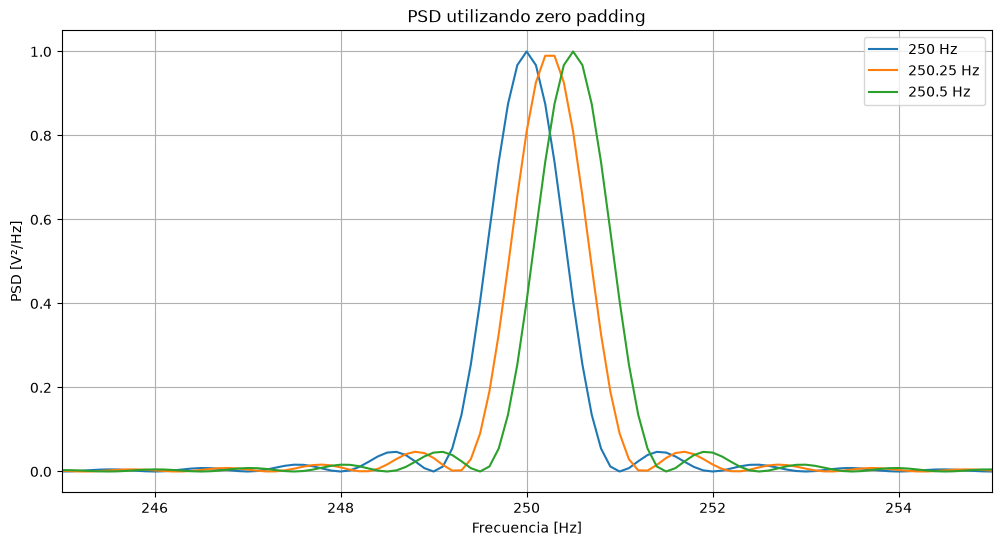

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    f_zp,
    PSD1_zp,
    label="250 Hz"
)

plt.plot(
    f_zp,
    PSD2_zp,
    label="250.25 Hz"
)

plt.plot(
    f_zp,
    PSD3_zp,
    label="250.5 Hz"
)

plt.title("PSD utilizando zero padding")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")

plt.xlim(245, 255)

plt.grid()
plt.legend()

plt.show()

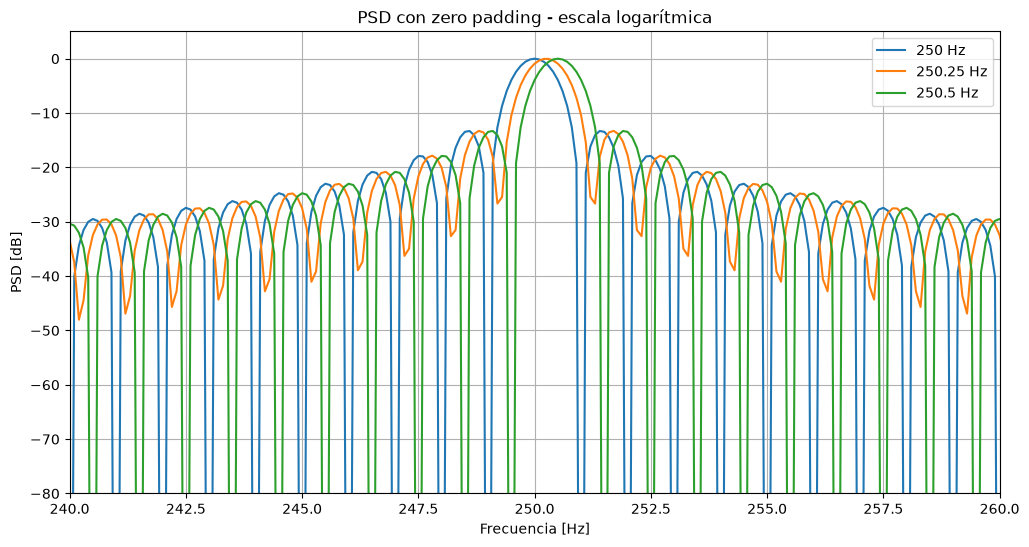

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    f_zp,
    10*np.log10(PSD1_zp + 1e-20),
    label="250 Hz"
)

plt.plot(
    f_zp,
    10*np.log10(PSD2_zp + 1e-20),
    label="250.25 Hz"
)

plt.plot(
    f_zp,
    10*np.log10(PSD3_zp + 1e-20),
    label="250.5 Hz"
)

plt.title("PSD con zero padding - escala logarítmica")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")

plt.xlim(240, 260)
plt.ylim(-80, 5)

plt.grid()
plt.legend()

plt.show()

## Análisis del zero padding

Al aplicar zero padding se obtiene una representación mucho más detallada de la forma del espectro.

La FFT original utiliza una separación entre bins de:

$$
1\text{ Hz}
$$

mientras que la FFT con zero padding evalúa el espectro cada:

$$
0.1\text{ Hz}
$$

Esto permite visualizar con mayor claridad la posición del máximo, el lóbulo principal y los lóbulos laterales producidos por la ventana rectangular implícita.

Sin embargo, el zero padding no agrega nueva información a la señal original.

La duración efectiva de la adquisición continúa siendo:

$$
T=\frac{N}{f_s}=1\text{ s}
$$

Por lo tanto, la capacidad física para separar dos componentes frecuenciales cercanas no mejora.

El zero padding puede interpretarse como una interpolación de la DFT: permite observar más puntos de la misma transformada, pero no modifica la información contenida en el registro original.

In [18]:
P1_zp = np.sum(PSD1_zp) * df_zp
P2_zp = np.sum(PSD2_zp) * df_zp
P3_zp = np.sum(PSD3_zp) * df_zp

print("Potencia señal 1 con zero padding =", P1_zp)
print("Potencia señal 2 con zero padding =", P2_zp)
print("Potencia señal 3 con zero padding =", P3_zp)

Potencia señal 1 con zero padding = 1.0000000000000004
Potencia señal 2 con zero padding = 0.9989999999999996
Potencia señal 3 con zero padding = 1.0000000000000004


La potencia obtenida después de realizar zero padding continúa siendo aproximadamente unitaria.

Esto confirma que agregar ceros no agrega ni elimina energía de la señal original.

El procedimiento solamente incrementa la cantidad de puntos con los que se evalúa el espectro.

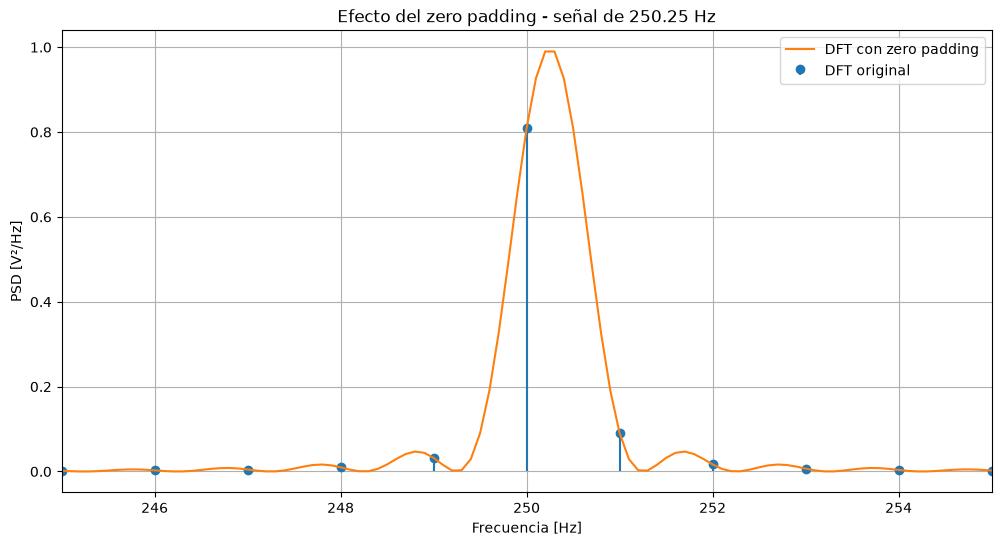

In [19]:
plt.figure(figsize=(12, 6))

# FFT original
plt.stem(
    f,
    PSD2,
    linefmt="C0-",
    markerfmt="C0o",
    basefmt=" ",
    label="DFT original"
)

# Zero padding
plt.plot(
    f_zp,
    PSD2_zp,
    "C1",
    label="DFT con zero padding"
)

plt.title("Efecto del zero padding - señal de 250.25 Hz")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")

plt.xlim(245, 255)

plt.grid()
plt.legend()

plt.show()

En la comparación entre la DFT original y la obtenida mediante zero padding se observa que los coeficientes de la FFT original pueden interpretarse como muestras de una función espectral subyacente.

El zero padding incorpora puntos intermedios y permite visualizar dicha forma con mayor detalle.

Esto explica por qué una señal desintonizada puede parecer tener su energía distribuida de manera irregular cuando se utilizan pocos puntos de DFT: solamente se están observando determinadas muestras de la respuesta espectral.

Al incrementar el número de puntos mediante zero padding, el fenómeno de leakage no desaparece. Por el contrario, puede observarse con mayor claridad.

# Conclusiones

El experimento permitió analizar el fenómeno de desparramo espectral asociado al cálculo de la DFT sobre registros temporales de duración finita.

Cuando la frecuencia de una senoidal coincide exactamente con uno de los bins de la DFT, el registro contiene un número entero de ciclos y prácticamente toda la potencia de la señal aparece concentrada en una única componente frecuencial.

En cambio, una pequeña desintonía respecto de la grilla de frecuencias provoca que la energía se distribuya entre múltiples bins, dando origen al denominado spectral leakage*.

Este resultado explica por qué señales cuyas frecuencias difieren apenas algunas fracciones de Hertz pueden presentar espectros visualmente muy diferentes. El factor determinante no es solamente la diferencia absoluta de frecuencia, sino la relación entre dicha frecuencia y los bins definidos por:

$$
f_k=k\frac{f_s}{N}
$$

La identidad de Parseval permitió comprobar que, a pesar del cambio en la distribución espectral, la potencia total de las tres señales permanece aproximadamente unitaria. Por lo tanto, el desparramo espectral no implica una pérdida de potencia, sino una redistribución de la misma entre diferentes componentes de la DFT.

Finalmente, mediante zero padding se incrementó la cantidad de puntos utilizados para representar el espectro. Esto permitió visualizar con mayor detalle el lóbulo principal y los lóbulos laterales asociados a la ventana temporal.

Sin embargo, el zero padding no incrementa la resolución espectral física del registro ni agrega información nueva. Su principal efecto es realizar una interpolación más densa del espectro obtenido a partir de las mismas muestras originales.